**Import the Dependenicies**

In [1]:
!pip install scikit-survival

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
from sklearn.model_selection import GridSearchCV, KFold

In [3]:
from sksurv.util import Surv

**Load the Data from Excel into Dataframes**

In [4]:
df_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WiDSWorldWide_GlobalDathon26/train.csv', index_col = "event_id")
df_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WiDSWorldWide_GlobalDathon26/test.csv', index_col = "event_id")
sample_submission = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WiDSWorldWide_GlobalDathon26/sample_submission.csv')
metadata = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WiDSWorldWide_GlobalDathon26/metaData.csv')

In [5]:
metadata.head()

,column,type,category,description,units,range
0,event_id,identifier,identifier,Anonymized fire event identifier (stable rando...,NaN,NaN
1,time_to_hit_hours,target,target,Time from t0+5h until fire comes within 5km of...,hours,"[0, 72]"
2,event,target,target,"Event indicator: 1 if fire hit within 72h, 0 i...",NaN,NaN
3,num_perimeters_0_5h,feature,temporal_coverage,Number of perimeters within first 5 hours,NaN,NaN
4,dt_first_last_0_5h,feature,temporal_coverage,Time span between first and last perimeter (ho...,NaN,NaN


In [6]:
df_test.head()

,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,...,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month
event_id,,,,,,,,,,,,,,,,,,,,,
10662602,1,0.000000,1,2.452217,0.000000,0.00000,0.000000,1.239017,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,3,7
13353600,1,0.000000,1,131.669588,0.000000,0.00000,0.000000,4.887862,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,22,0,8
13942327,1,0.000000,1,6.723104,0.000000,0.00000,0.000000,2.044216,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,2,6,7
16112781,1,0.000000,1,285.416736,0.000000,0.00000,0.000000,5.657448,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,1,7
17132808,7,3.459331,0,61.098604,12.516633,0.20486,3.618224,4.128724,2.603921,0.186363,...,13.54413,-22.687575,0.044572,0.15855,0.15855,-24.414806,3.920562,23,5,7


In [7]:
# Sample submission data
sample_submission.head()

,event_id,prob_12h,prob_24h,prob_48h,prob_72h
0,10662602,0.5,0.5,0.5,0.5
1,13353600,0.5,0.5,0.5,0.5
2,13942327,0.5,0.5,0.5,0.5
3,16112781,0.5,0.5,0.5,0.5
4,17132808,0.5,0.5,0.5,0.5


**Exploratory Data Analysis (EDA)**

In [8]:
df_train.head()

,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
event_id,,,,,,,,,,,,,,,,,,,,,
10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,0.03545,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,0.00000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,0.00000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,0.00000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


In [9]:
print("Shape: ", df_train.shape)
print(df_train.info())

Shape:  (221, 36)
<class 'pandas.core.frame.DataFrame'>
Index: 221 entries, 10892457 to 99339733
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   num_perimeters_0_5h           221 non-null    int64  
 1   dt_first_last_0_5h            221 non-null    float64
 2   low_temporal_resolution_0_5h  221 non-null    int64  
 3   area_first_ha                 221 non-null    float64
 4   area_growth_abs_0_5h          221 non-null    float64
 5   area_growth_rel_0_5h          221 non-null    float64
 6   area_growth_rate_ha_per_h     221 non-null    float64
 7   log1p_area_first              221 non-null    float64
 8   log1p_growth                  221 non-null    float64
 9   log_area_ratio_0_5h           221 non-null    float64
 10  relative_growth_0_5h          221 non-null    float64
 11  radial_growth_m               221 non-null    float64
 12  radial_growth_rate_m_per_h    221 non-n

In [10]:
# Time that had the most numbers of event starting-time observations
event_start_hour = df_train["event_start_hour"].value_counts()
event_start_hour


,count
event_start_hour,
21,33
22,30
20,23
18,20
23,18
0,16
19,13
16,11
2,9


In [11]:
# High values for both features signifies an aggressive mobile fire
df_train[["area_growth_rate_ha_per_h", "centroid_speed_m_per_h"]].sort_values(by = "centroid_speed_m_per_h",ascending = False ).head()

,area_growth_rate_ha_per_h,centroid_speed_m_per_h
event_id,,
70401139,182.820074,595.058697
60132804,520.443033,424.426546
59863246,124.525831,258.006167
80550714,88.573191,235.166604
84940844,31.054997,216.184540


In [12]:
# Fire directly approaching evac zone quickly (When both features are high)
df_train[["closing_speed_m_per_h", "alignment_abs"]].sort_values(by = "closing_speed_m_per_h", ascending = False).head()

,closing_speed_m_per_h,alignment_abs
event_id,,
60132804,354.120897,0.902628
49907151,134.637726,0.994594
65120642,93.922570,0.796469
69453871,25.336113,0.326959
54555851,18.506421,0.231012


In [13]:
# What percentage of fires hit?
event = (df_train["event"]).value_counts()
event

,count
event,
0,152
1,69


In [14]:
# Unique area growth rate where fire hit evacuation zones(event = 1) within 72h
df_train["area_growth_rate_ha_per_h"][df_train["event"] == 1].unique()

array([ 0.00000000e+00,  4.16444985e+00,  8.19766902e+00,  1.07844859e+01,
        3.44630084e+00,  5.54749656e-04,  3.18730805e+00,  3.01816268e+00,
        6.50236167e+01,  2.90669901e+01,  5.20443033e+02,  1.32352921e+01,
        1.68409928e+02,  1.82820074e+02,  7.03124540e+00, -5.29284592e-06,
        8.85731908e+01,  3.10549968e+01,  6.62920158e-04])

In [15]:
df_train["event_start_hour"].describe()

,event_start_hour
count,221.000000
mean,15.429864
std,7.921250
min,0.000000
25%,9.000000
50%,19.000000
75%,21.000000
max,23.000000


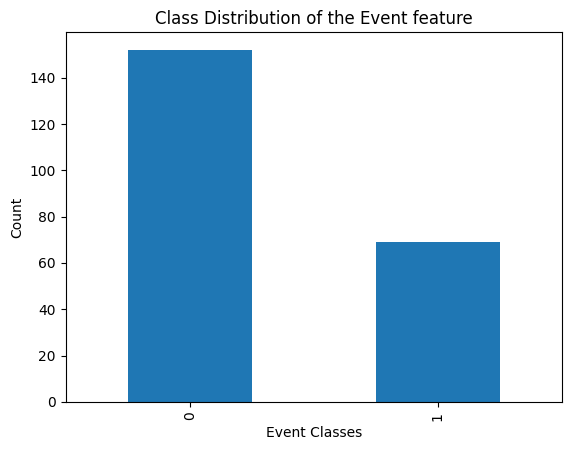

In [16]:
# Bar chart of the event classes
event.plot(
    kind = "bar",
    )

plt.xlabel("Event Classes")
plt.ylabel("Count")
plt.title("Class Distribution of the Event feature");

<Axes: xlabel='event', ylabel='event_start_hour'>

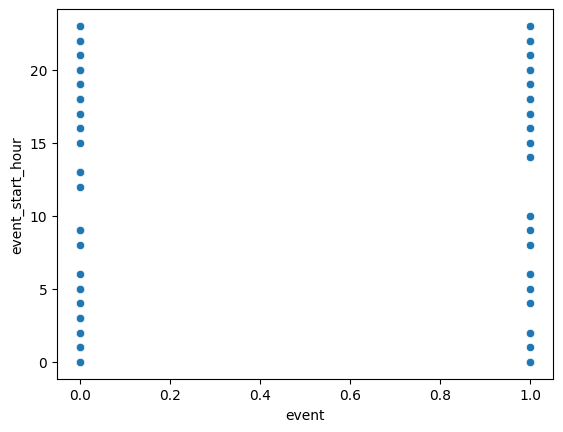

In [17]:
sns.scatterplot(
    x = df_train["event"],
    y = df_train["event_start_hour"]
)

In [18]:
df_train["time_to_hit_hours"].unique()

array([1.88925118e+01, 2.20481080e+01, 8.88895483e-01, 6.09530215e+01,
       4.49902745e+01, 4.40263836e+01, 1.48453918e+01, 6.67679270e+01,
       3.99126301e+01, 5.46381094e+01, 6.66439690e+01, 1.59246879e+01,
       1.09074590e+01, 1.82804653e+01, 5.54643427e+01, 6.45674854e+01,
       2.38438434e+01, 3.53484561e+00, 5.81815958e+00, 6.64281031e+01,
       3.73947605e+01, 2.41724995e+01, 6.64422306e+01, 6.12658726e+01,
       5.23763411e-01, 5.76438066e+01, 1.39796932e+00, 2.56443962e+00,
       6.28166641e+01, 4.89252955e+01, 5.84172862e-01, 5.45866301e+00,
       3.76167108e+01, 6.62710855e+01, 6.37164247e+01, 1.88046103e+01,
       3.21134343e+00, 1.47281399e+01, 6.64039128e+01, 6.56896544e+01,
       6.64489979e+01, 1.12543443e+01, 1.47523102e+00, 1.99296374e+00,
       4.44304912e+00, 1.28211783e+01, 5.97708404e+01, 1.57785977e+00,
       6.03139902e+01, 6.14817681e+01, 4.79970215e+01, 6.50849293e+01,
       6.62960358e+01, 1.36567870e+01, 2.10724622e+01, 6.61317720e+01,
      

From above observations, most fires that hit (event = 1), they started at 7pm; median(50%) = 19. <br> Also, event = 1 has some outliers, represented by the circles before the minimum mark.

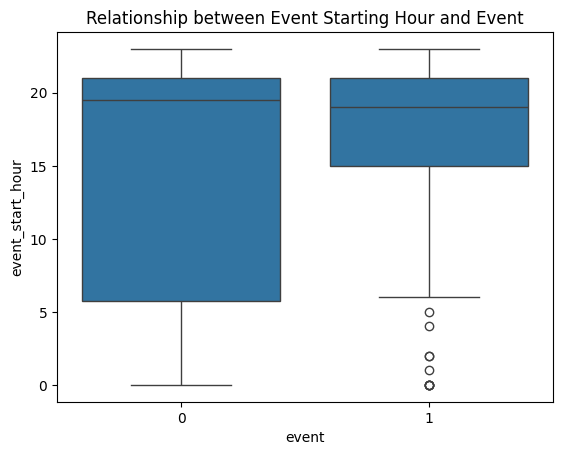

In [19]:
# At what time time did most fires hit?
sns.boxplot(
    x = df_train["event"],
    y = df_train["event_start_hour"]
)
plt.title("Relationship between Event Starting Hour and Event");

In [20]:
event_class = df_train["event"].value_counts()
event_class

,count
event,
0,152
1,69


In [21]:
# Correlation between all features except the target features
corr = df_train.drop(columns = ["time_to_hit_hours", "event"]).corr()
print("Correlation matrix: ")
corr.head()

Correlation matrix: 


,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,...,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month
num_perimeters_0_5h,1.000000,0.667314,-0.673017,-0.117057,0.474259,0.502281,0.522499,-0.109423,0.784831,0.724456,...,0.315076,-0.267586,0.436162,0.077316,0.590605,0.172545,0.074457,0.156423,0.010015,-0.043686
dt_first_last_0_5h,0.667314,1.000000,-0.923622,-0.172628,0.281809,0.195953,0.289782,-0.198299,0.514515,0.345499,...,0.180727,-0.203947,0.497341,0.035579,0.823127,0.062732,0.083141,0.202332,-0.005273,0.014960
low_temporal_resolution_0_5h,-0.673017,-0.923622,1.000000,0.199176,-0.230652,-0.225602,-0.250207,0.281554,-0.476915,-0.357717,...,-0.131277,0.143319,-0.439878,0.022043,-0.861182,-0.070261,-0.019370,-0.184362,-0.007760,-0.026156
area_first_ha,-0.117057,-0.172628,0.199176,1.000000,0.037155,-0.044999,0.029056,0.621912,-0.046068,-0.058269,...,0.043750,-0.033100,-0.058690,0.019055,-0.171052,-0.049385,0.043538,-0.184683,0.064508,-0.019375
area_growth_abs_0_5h,0.474259,0.281809,-0.230652,0.037155,1.000000,0.325878,0.991339,0.103716,0.669160,0.486166,...,0.855030,-0.737906,0.344149,0.177724,0.220966,-0.122571,0.418101,0.067744,-0.041576,-0.078409


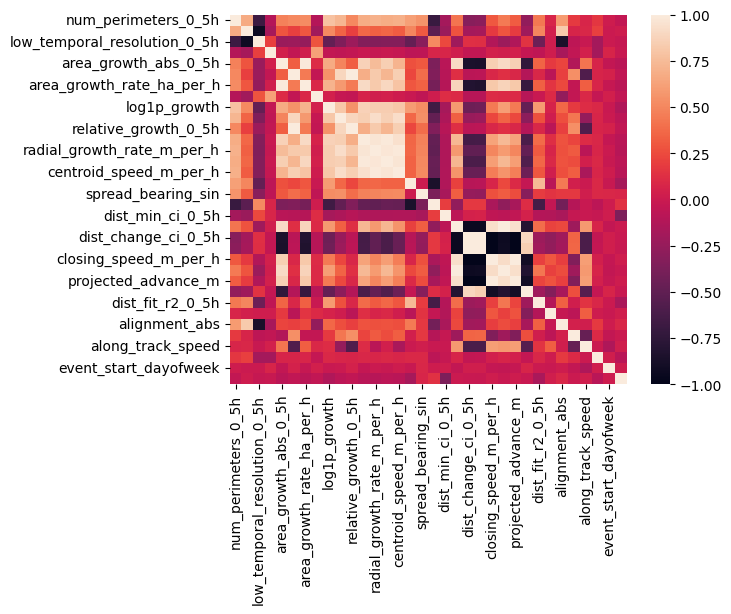

In [22]:
sns.heatmap(corr);
# The heatmap shows signs of multicollinearity

In [23]:
# Filter columns with high correlation while omitting self targets(corr = 1.0)
high_corr = corr[(corr > 0.80) & (corr < 1.00)]
filtered_df = high_corr.stack().reset_index()
filtered_df.columns = ['feature_1', 'feature_2', 'correlation']
filtered_df.sort_values(by = "correlation", ascending=False)

,feature_1,feature_2,correlation
85,projected_advance_m,closing_speed_m_per_h,0.998166
76,closing_speed_m_per_h,projected_advance_m,0.998166
66,dist_std_ci_0_5h,closing_speed_abs_m_per_h,0.996875
79,closing_speed_abs_m_per_h,dist_std_ci_0_5h,0.996875
70,dist_slope_ci_0_5h,dist_change_ci_0_5h,0.993057
...,...,...,...
16,area_growth_rate_ha_per_h,closing_speed_m_per_h,0.815404
23,log1p_growth,centroid_speed_m_per_h,0.812041
57,centroid_speed_m_per_h,log1p_growth,0.812041
25,log_area_ratio_0_5h,log1p_growth,0.810486


In [24]:
# Identify the columns to drop
cols = []

# Remove redundant transforms
cols.extend([
    "area_growth_rel_0_5h",
    "relative_growth_0_5h",
    "log1p_growth"
      ]
    )

# Remove nearly duplicate in terms of area growth
cols.append("area_growth_abs_0_5h")

# Remove nearly similar in terms of speed
cols.extend(
    [
        "closing_speed_m_per_h",
        "closing_speed_abs_m_per_h",
        "dist_std_ci_0_5h"
    ]
)

# Radial growth is better than centroid movement
cols.extend(
    [
        "centroid_displacement_m",
        "radial_growth_rate_m_per_h",
        "centroid_speed_m_per_h"
    ]
)

# Remove acceleration redundancy
cols.extend(
    [
        "dist_change_ci_0_5h",
        "dist_slope_ci_0_5h"
    ]
)

print(len(cols))


12


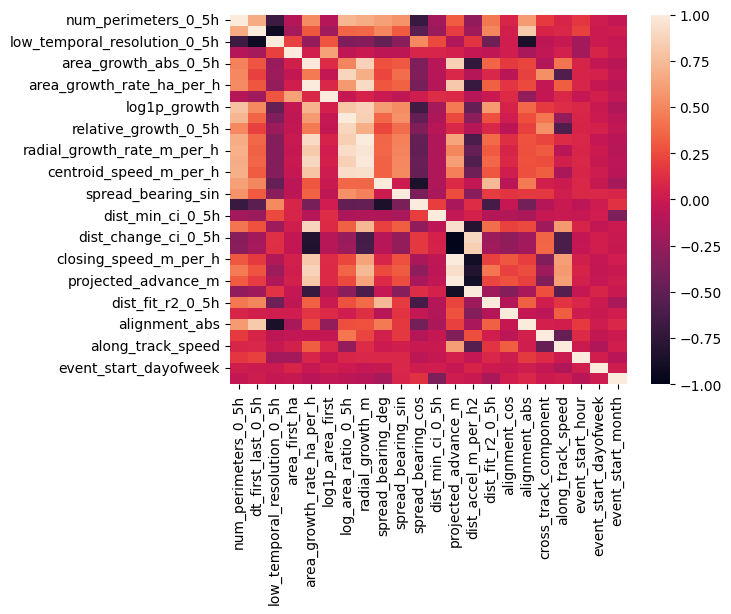

In [25]:
sns.heatmap(corr.drop(columns=cols));

In [26]:
# Recast the event column as boolean type
df_train["event"] = df_train["event"].astype(bool)

In [27]:
df_train["event"].head()

,event
event_id,
10892457,False
11757157,True
11945086,True
12044083,False
12052347,False


In [28]:
# Identify the feature matrix (X) and the target vector (y)
target = ["event", "time_to_hit_hours"]
X_train = df_train.drop(columns = target)
y_train = df_train[target]

In [29]:
# The model is sensitive about the format of data hence converted to compatible arrays using surv class
y_train = Surv.from_arrays(event=df_train[target[0]], time=df_train[target[1]])

In [30]:
y_train[:5]

array([(False, 18.89251185), ( True, 22.04810801), ( True,  0.88889548),
       (False, 60.95302147), (False, 44.99027447)],
      dtype=[('event', '?'), ('time', '<f8')])

In [31]:
len(y_train)

221

In [32]:
# Number of rows & columns in training feature matrix and target vector
print(X_train.shape)
print(y_train.shape)

(221, 34)
(221,)


**Build Model using Coxnet Survival Analysis without dropping the highly correlated features**

In [33]:
# Instantiate the model
model = CoxnetSurvivalAnalysis(
    fit_baseline_model = True
)

**Cross Validation**

In [34]:
param_grid = {
    'l1_ratio':        [0.01, 0.1, 0.5, 0.9, 1.0],
    'alpha_min_ratio': [0.01, 0.1, 0.5]
}

cv = KFold(
    n_splits = 10,
    shuffle = True,
    random_state = 42
)
cross_val = GridSearchCV(
    estimator = model,
    param_grid = param_grid,
    cv = cv,
    n_jobs = -1,
    verbose = 1
)

In [35]:
cross_val.fit(X_train, y_train)

Fitting 10 folds for each of 15 candidates, totalling 150 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",CoxnetSurviva...ne_model=True)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha_min_ratio': [0.01, 0.1, ...], 'l1_ratio': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >

In [36]:
cross_val.best_score_

np.float64(0.923680875738531)

In [37]:
# Get the survival function and transform into a Dataframe
def survival_function(model):
  surv_function = model.predict_survival_function(df_test)
  df = pd.DataFrame(
    [fn(fn.x) for fn in surv_function],
    columns=surv_function[0].x,
    index=df_test.index
  )
  return df, surv_function

In [38]:
coxnet_func = survival_function(cross_val.best_estimator_)
coxnet_func[0].head()

,0.001220,0.007176,0.064361,0.130320,0.132979,0.292272,0.374486,0.376566,0.410032,0.508562,...,66.640791,66.643969,66.662944,66.727421,66.767927,66.790141,66.859891,66.920463,66.966919,66.994474
event_id,,,,,,,,,,,,,,,,,,,,,
10662602,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
13353600,0.988735,0.977453,0.966166,0.954839,0.943469,0.932106,0.932106,0.920690,0.909250,0.897757,...,0.151320,0.151320,0.151320,0.151320,0.151320,0.151320,0.151320,0.059847,0.059847,0.059847
13942327,0.999642,0.999280,0.998913,0.998541,0.998163,0.997781,0.997781,0.997393,0.996999,0.996599,...,0.942089,0.942089,0.942089,0.942089,0.942089,0.942089,0.942089,0.914882,0.914882,0.914882
16112781,0.988092,0.976174,0.964257,0.952308,0.940320,0.928349,0.928349,0.916330,0.904294,0.892212,...,0.135763,0.135763,0.135763,0.135763,0.135763,0.135763,0.135763,0.050908,0.050908,0.050908
17132808,0.999806,0.999610,0.999411,0.999210,0.999005,0.998798,0.998798,0.998587,0.998374,0.998156,...,0.968207,0.968207,0.968207,0.968207,0.968207,0.968207,0.968207,0.952962,0.952962,0.952962


In [39]:
# Probability times as per the sample_submission.csv guide
times = [12, 24, 48, 72]

# Predict survival time at specified times
# last known value is equivalent to t=72
def predict(fn, t):
    t_clipped = np.clip(t, fn.domain[0], fn.domain[1])
    return fn(t_clipped)

def predict_probs(X):
  surv_probs = pd.DataFrame(
    {
        f"prob_{t}h": [predict(fn, t)
          for fn in coxnet_func[1]]
           for t in times},
          index=X.index
  )

  return surv_probs

coxnet_probs = predict_probs(df_test)
coxnet_probs.head()


,prob_12h,prob_24h,prob_48h,prob_72h
event_id,,,,
10662602,1.000000,1.000000,1.000000,1.000000
13353600,0.425922,0.239205,0.187689,0.059847
13942327,0.973397,0.955816,0.948521,0.914882
16112781,0.405541,0.220333,0.170489,0.050908
17132808,0.985503,0.975823,0.971782,0.952962


In [40]:
cross_val.best_estimator_.score(X_train, y_train)

np.float64(0.9094898973169924)

In [41]:
n_events   = y_train['event'].sum()
n_features = X_train.shape[1]
epv        = n_events / n_features

epv

np.float64(2.0294117647058822)

In [45]:
coefs = pd.Series(
    cross_val.best_estimator_.coef_[:, -1],
    index=X_train.columns
)
coefs.head()

,0
num_perimeters_0_5h,0.0
dt_first_last_0_5h,0.0
low_temporal_resolution_0_5h,0.0
area_first_ha,0.0
area_growth_abs_0_5h,0.0
